# Notebook 1: Neural Network Fundamentals & Backpropagation

Ghana AI Talent Accelerator - Deep Learning Foundations

Speedykom Group GmbH

## Learning Objectives

At the end of this notebook, you will be able to:

- **Understand neural network architecture**: Layers, neurons, weights,
  biases
- **Explain activation functions**: ReLU, Sigmoid, Softmax and when to
  use each
- **Understand forward pass**: How data flows through the network
- **Grasp backpropagation intuitively**: How networks learn (not the
  math, just the concept)
- **Know loss functions**: Cross-entropy for classification, MSE for
  regression
- **Understand optimizers**: SGD and Adam for adjusting weights
- **Identify overfitting and underfitting** in neural networks
- **Interpret learning curves**: Loss vs. epochs
- **Know why GPUs matter**: Parallel computation speeds up training
  dramatically
- **Set up Google Colab** for free GPU access

------------------------------------------------------------------------

## Why Deep Learning: When Traditional ML Isn’t Enough

### The Limitation of Traditional Machine Learning

**Traditional ML (Linear Regression, Decision Trees)** works great
when: - **Inputs are simple numbers**: Age, salary, credit score -
**Relationships are somewhat linear**: Double the salary → roughly
double the loan approval rate - **You have \<1 million data points**:
Processing is fast

**But fails spectacularly when**:

**Problem 1: Image Recognition**

Traditional ML approach:

``` python
# Image of a car: 800 x 600 pixels = 480,000 pixel values
# Traditional ML needs to work with all 480,000 inputs directly
# Result: Model is gigantic, slow, and fragile (rotated car = unrecognized)
```

**Deep Learning approach**: - Layer 1: Detects edges (vertical,
horizontal, diagonal lines) - Layer 2: Combines edges into shapes
(circles, rectangles, triangles) - Layer 3: Combines shapes into parts
(wheels, windows, doors) - Layer 4: Combines parts into objects (car!)

**Key insight**: Deep learning learns **hierarchies of patterns**. A
rotated car still has wheels and windows.

**Problem 2: Language Understanding**

Traditional ML: “Give me 50 hand-crafted features of this sentence and
I’ll classify it.”

Deep Learning: “I’ll read billions of sentences and learn what language
patterns mean.”

Result: ChatGPT can write essays. Traditional ML can barely understand
sentences.

### Real-World Application: Computer Vision

**How does Google Photos recognize your face?**

1.  **Deep Learning model trained on**: Billions of faces (with
    permission)
2.  **Learns patterns**: Eye distance, nose shape, facial structure
3.  **When you upload photo**: Model outputs → “95% confident this is
    \[person\]”
4.  **Result**: Photos organized by person automatically

**How does it detect cars in images?**

Same process: - Trained on images of cars (from angles, lighting,
weather) - Learns: “Rectangular shape with wheels underneath = car” -
Can detect: Cars, trucks, motorcycles, in daylight/night/rain

### Real Scenarios in Ghana

**Traffic Enforcement**: - Camera at intersection takes photo - Deep
Learning detects: Car number plate - Reads: License plate characters -
Knows: Is this car registered? Does it have valid insurance? -
**Result**: Automatic enforcement without police

**Border Security**: - Camera at border - Deep Learning detects: Human
faces - Recognizes: “This person is on watchlist” - **Result**: Enhanced
security

**Manufacturing Quality Control**: - Factory produces phone screens -
Deep Learning inspects: Defects, scratches, dead pixels - Humans can’t
check 1000 screens/hour; AI can - **Result**: Higher quality, fewer
defects

### Why Deep Learning Needs GPUs

Traditional ML on laptop: Fast ✅

Deep Learning training: - **Laptop (CPU)**: 48 hours to train - **Google
Colab (Free GPU)**: 2 hours to train - **Cloud GPU (paid)**: 15 minutes
to train

GPUs are specialized for the **parallel computation** that deep learning
requires.

------------------------------------------------------------------------

<a href="https://colab.research.google.com/github/Speedykom/GIZ_GhanaAI_Training_Materials/blob/main/06-deep-learning/intro_DL1.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

> **IMPORTANT: Enable GPU Before Running!**
>
> **Before you run any code, you MUST enable GPU acceleration:**
>
> 1.  Click **Runtime** in the top menu
> 2.  Select **Change runtime type**
> 3.  Under **Hardware accelerator**, select **T4 GPU**
> 4.  Click **Save**
>
> Without GPU, training will be extremely slow (or may not work
> properly).

# Philosophy: First the Fire, Then the Physics

Most courses teach you how to build a carburetor before letting you
drive a car. **We do the opposite.**

We start by training a working model. Once you’ve seen it work, we peel
back the layers to understand why. This “Top-Down” approach, pioneered
by Jeremy Howard (fast.ai), ensures you stay motivated by solving real
problems immediately.

**Day One Goal:** Train a rain predictor in 30 minutes.  
**Day Thirty Goal:** Understand why changing the learning rate from
0.001 to 0.01 collapsed your loss curve.

This follows the mantra: **“You don’t need to understand the carburetor
to drive a car, but you’ll want to when it breaks down.”**

> **Why Are We Moving to Google Colab? (The Bicycle vs. The Cargo
> Ship)**
>
> You might be wondering why we are using Google Colab for this module.
>
> Think of **traditional Machine Learning** (like predicting house
> prices) as moving 50 boxes across town. You can easily do that on a
> **bicycle** (your laptop’s CPU).
>
> **Deep Learning** (especially with images and large datasets) requires
> moving *millions* of boxes at once. If you use your laptop CPU, it
> will take weeks! A **GPU** (Graphics Processing Unit) is like a
> massive **Cargo Ship** that moves all those boxes simultaneously.
>
> Google Colab gives us free, temporary access to one of these Cargo
> Ships in the cloud. Let’s set sail!

------------------------------------------------------------------------

# The Problem: Will It Rain Tomorrow?

## Why This Problem?

We’re going to build a neural network that predicts whether it will rain
tomorrow based on today’s weather data. This is a perfect first problem
because:

- **Relatable**: Everyone understands weather
- **Tabular data**: Simple numbers, not complex images
- **Binary classification**: Yes/No answer (easier than 10-class digit
  classification)
- **Real data**: Australian weather measurements from multiple stations
- **Class imbalance**: Teaches important real-world challenges

## The Dataset

We’ll use the Australian Weather dataset, which contains daily
measurements from multiple weather stations. Each row represents one
day’s weather with features like:

- **Rainfall**: How much rain fell today (mm)
- **Humidity3pm**: Humidity percentage at 3 PM
- **Pressure9am**: Atmospheric pressure at 9 AM (hPa)
- **RainToday**: Did it rain today? (Yes/No)
- **RainTomorrow**: Will it rain tomorrow? (Yes/No) ← Our target

Let’s load and explore the data:

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Set style for plots
sns.set(style='whitegrid', palette='muted', font_scale=1.2)
%matplotlib inline

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Device setup - use GPU if available
import warnings
warnings.filterwarnings('ignore')
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0

### Load the Data

We’ll use the Australian Weather dataset from the provided URL:

In [2]:
# Download and load the weather dataset
url = "https://raw.githubusercontent.com/gchoi/Dataset/refs/heads/master/weatherAUS.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (36881, 24)

First 5 rows:
        Date      Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  5/18/2009        Hobart      5.1     14.3       0.0          1.8       8.9   
1   7/3/2009    Launceston      1.1     14.5       0.4          NaN       NaN   
2  2/18/2010   Williamtown     19.7     26.2       0.0          7.2       7.2   
3   3/4/2010  PerthAirport     16.6     28.0       0.0          9.0      11.3   
4   9/9/2010     GoldCoast     14.6     25.3       0.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity3pm  Pressure9am  \
0          NW           30.0        WSW  ...        47.0       1023.1   
1         SSW           50.0          E  ...        46.0       1001.5   
2         SSE           41.0        SSE  ...        50.0       1020.9   
3          SW           54.0        SSE  ...        41.0       1018.3   
4         NNW           43.0        WNW  ...        67.0       1020.3   

   Pressure3pm  Cloud9am  Cloud3

### Data Preprocessing

Neural networks only understand numbers. We need to:

1.  Select relevant features (we’ll use 4 key features for simplicity)
2.  Convert “Yes”/“No” to 1/0
3.  Handle any missing values
4.  Split into features (X) and target (y)
5.  Convert to PyTorch tensors

In [3]:
# Select the features we want to use
# We'll focus on these 4 features that are good predictors of rain:
features = ['Rainfall', 'Humidity3pm', 'Pressure9am', 'RainToday', 'RainTomorrow']
df = df[features].copy()

print("Selected columns:")
print(df.columns.tolist())
print(f"\nDataset shape: {df.shape}")

# Check the first few rows
print("\nFirst 5 rows:")
print(df.head())

Selected columns:
['Rainfall', 'Humidity3pm', 'Pressure9am', 'RainToday', 'RainTomorrow']

Dataset shape: (36881, 5)

First 5 rows:
   Rainfall  Humidity3pm  Pressure9am RainToday RainTomorrow
0       0.0         47.0       1023.1        No           No
1       0.4         46.0       1001.5        No           No
2       0.0         50.0       1020.9        No           No
3       0.0         41.0       1018.3        No           No
4       0.0         67.0       1020.3        No           No

In [4]:
# Convert categorical variables to numeric
df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal rows: {len(df)}")

# Drop any rows with missing values (simple approach for this tutorial)
df = df.dropna()

print(f"\nDataset shape after cleaning: {df.shape}")
print("\nData types:")
print(df.dtypes)

Missing values per column:
Rainfall         626
Humidity3pm      511
Pressure9am     3572
RainToday        626
RainTomorrow     620
dtype: int64

Total rows: 36881

Dataset shape after cleaning: (32545, 5)

Data types:
Rainfall        float64
Humidity3pm     float64
Pressure9am     float64
RainToday       float64
RainTomorrow    float64
dtype: object

### Understanding Class Imbalance

Class distribution:
RainTomorrow
0.0    24933
1.0     7612
Name: count, dtype: int64

Percentage:
RainTomorrow
0.0    76.61
1.0    23.39
Name: count, dtype: float64

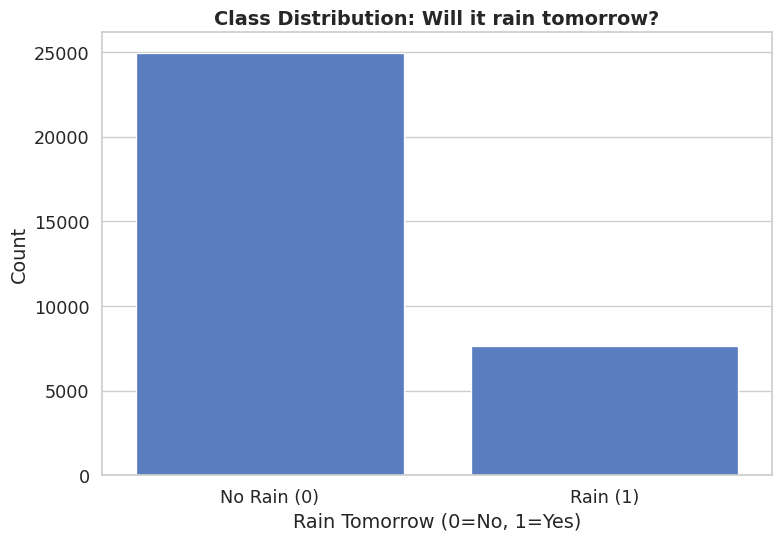

In [5]:
# Check class distribution
class_counts = df['RainTomorrow'].value_counts()
print("Class distribution:")
print(class_counts)
print(f"\nPercentage:")
print((class_counts / len(df) * 100).round(2))

# Visualize
plt.figure(figsize=(9, 6))
sns.countplot(x='RainTomorrow', data=df)
plt.title('Class Distribution: Will it rain tomorrow?', fontweight='bold')
plt.xlabel('Rain Tomorrow (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Rain (0)', 'Rain (1)'])
plt.show()

**Key Insight**: About 78% of days have no rain tomorrow, and 22% have
rain. This is **class imbalance** - a model that always predicts “no
rain” would be 78% accurate! We’ll need to be careful about this.

------------------------------------------------------------------------

# Building Our First Neural Network

## From Linear Regression to Neural Networks

> **Mental Model: The Corporate Office**
>
> Think of a Neural Network as a **corporate office** trying to make a
> decision (e.g., “Will it rain tomorrow?”).
>
> - **Input Layer (The Interns):** They each look at one raw piece of
>   data. Intern A checks humidity. Intern B checks pressure. They pass
>   their notes upward.
>
> - **Hidden Layer (The Managers):** They receive the notes from all
>   interns. They combine information. “Ah! Intern A says humidity is
>   HIGH and Intern B says pressure is DROPPING. I’m flagging this as a
>   storm risk!” They pass summaries upward.
>
> - **Output Layer (The Boss):** The boss receives all the managers’
>   summaries and makes the final 0 or 1 decision.
>
> **Training (Backpropagation):** When the prediction is wrong, the boss
> yells at the managers, who yell at the interns, and everyone adjusts
> how much they weight each factor. Eventually, they learn the right
> recipe for predicting rain!

**Reminder**: In traditional machine learning, Linear Regression finds:
$$\hat{y} = w_1 x_1 + w_2 x_2 + w_3 x_3 + w_4 x_4 + b$$

This works for linear relationships, but weather is complex. What if:

- High humidity AND low pressure together matter more than either alone?
- The relationship isn’t a straight line?

**Neural Network Insight**: Stack multiple linear transformations with
non-linear activations:

$$\text{Layer 1: } h = W_1 \cdot x + b_1$$
$$\text{Activation: } a = \text{relu}(h)$$
$$\text{Layer 2: } \hat{y} = \text{sigmoid}(W_2 \cdot a + b_2)$$

## Our Network Architecture

For our rain prediction, we’ll build a simple network:

- **Input**: 4 features (Rainfall, Humidity3pm, Pressure9am, RainToday)
- **Hidden Layer 1**: 5 neurons with ReLU activation
- **Hidden Layer 2**: 3 neurons with ReLU activation  
- **Output**: 1 neuron with Sigmoid activation (probability of rain)

In [6]:
# Prepare data for PyTorch
# Features: Rainfall, Humidity3pm, Pressure9am, RainToday
# Target: RainTomorrow
feature_cols = ['Rainfall', 'Humidity3pm', 'Pressure9am', 'RainToday']
X = df[feature_cols].values
y = df['RainTomorrow'].values

print("Features used:")
for i, col in enumerate(feature_cols):
    print(f"  {i+1}. {col}")

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Convert to PyTorch tensors
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float()

print(f"\nTraining samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Input features: {X_train.shape[1]}")

Features used:
  1. Rainfall
  2. Humidity3pm
  3. Pressure9am
  4. RainToday

Training samples: 26036
Test samples: 6509
Input features: 4

### Define the Model

In [7]:
class RainPredictor(nn.Module):
    """
    A neural network to predict if it will rain tomorrow.
    
    Architecture:
    - Input: 4 features
    - Hidden 1: 5 neurons (ReLU)
    - Hidden 2: 3 neurons (ReLU)
    - Output: 1 neuron (Sigmoid for binary classification)
    """
    def __init__(self, n_features):
        super(RainPredictor, self).__init__()
        self.fc1 = nn.Linear(n_features, 5)
        self.fc2 = nn.Linear(5, 3)
        self.fc3 = nn.Linear(3, 1)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

# Create model
model = RainPredictor(X_train.shape[1])
print("Model Architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

Model Architecture:
RainPredictor(
  (fc1): Linear(in_features=4, out_features=5, bias=True)
  (fc2): Linear(in_features=5, out_features=3, bias=True)
  (fc3): Linear(in_features=3, out_features=1, bias=True)
)

Total parameters: 47

### Visualizing a Single Neuron

Before we understand the full network, let’s see what a single neuron
does. Each neuron receives inputs, multiplies them by weights, adds a
bias, and applies an activation function:

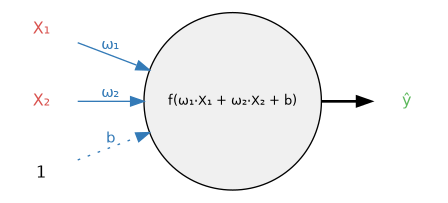

**Formula**: Output of neuron = **ŷ = f(ω₁·X₁ + ω₂·X₂ + b)**

**How it works:**

- **Inputs** (X₁, X₂): The data coming in (e.g., rainfall, humidity)
- **Weights** (ω₁, ω₂): How much each input matters (learned during
  training)
- **Bias** (b): An adjustable offset (learned during training)
- **Activation function** (f): Introduces non-linearity (ReLU, Sigmoid,
  etc.)
- **Output** (ŷ, “y-hat”): The neuron’s predicted output

A neural network is just many of these neurons connected together!

------------------------------------------------------------------------

## Why Activation Functions? The Linearity Trap

Here’s a sobering truth: **without activation functions, a 100-layer
neural network is just a single linear transformation.**

Think about it mathematically: - Layer 1 computes: **y₁ = W₁·x + b₁** (a
linear function) - Layer 2 computes: **y₂ = W₂·y₁ + b₂ = W₂·(W₁·x +
b₁) + b₂** (expand it out…) - This simplifies to: **y₂ = (W₂·W₁)·x +
(W₂·b₁ + b₂)** (still just one linear function!) - Layer 3: **y₃ =
W₃·y₂ + b₃** (still linear…)

**No matter how many layers you stack, you still have just one giant
linear equation:**
$$\text{Output} = W_{\text{combined}} \cdot x + b_{\text{combined}}$$

**Why does this matter?** Linear functions can only learn linear
decision boundaries. If your problem requires learning “humidity is HIGH
**AND** pressure is LOW → rain”, that’s a non-linear pattern
(multiplication of two things!). Linear models can’t do it.

**The Solution: Activation Functions**

An activation function introduces **non-linearity** between layers: -
Layer 1: **y₁ = ReLU(W₁·x + b₁)** (still linear inside, but ReLU is
non-linear!) - Layer 2: **y₂ = ReLU(W₂·y₁ + b₂)** (now y₁ is already
transformed by ReLU) - Layer 3: **y₃ = ReLU(W₃·y₂ + b₃)** (now y₂ is
transformed)

Now the function is **deeply non-linear**. Each layer can learn complex
patterns, and the combinations create even more complex patterns.

**Real-world impact:** - Without activation: Your “rain prediction”
network might learn “humidity + pressure”, but never “humidity AND
pressure” - With activation: Your network learns “if humidity \> 80 AND
pressure \< 1010, then rain is likely”

This is why activation functions are the magic ingredient that makes
deep learning work.

### Understanding Activation Functions

> **Mental Model: The Bouncer at the Club (ReLU)**
>
> Activation functions sound scary, but ReLU is just a **strict bouncer
> at a nightclub**:
>
> - If a number is **negative** (bad vibes): The bouncer shouts **“Zero!
>   You don’t get in!”**
> - If a number is **positive** (good vibes): The bouncer says **“Come
>   right in exactly as you are!”**
>
> **Why do we need a bouncer?**
>
> Without activation functions, stacking layers is useless—it’s just one
> giant linear equation. The bouncer adds **non-linearity**, allowing
> the network to learn complex patterns like “Only trigger rain warning
> if humidity is HIGH AND pressure is LOW” (combining two things!).
>
> Think of it like adding spices to cooking. Without spices
> (activations), everything tastes bland (linear). With spices, you get
> complex flavors (non-linear patterns)!

**ReLU (Rectified Linear Unit)**: $$\text{ReLU}(x) = \max(0, x)$$

If the input is negative, output 0. If positive, pass it through. This
introduces non-linearity.

**Sigmoid**: $$\text{Sigmoid}(x) = \frac{1}{1 + e^{-x}}$$

Squishes any value to be between 0 and 1, giving us a probability.

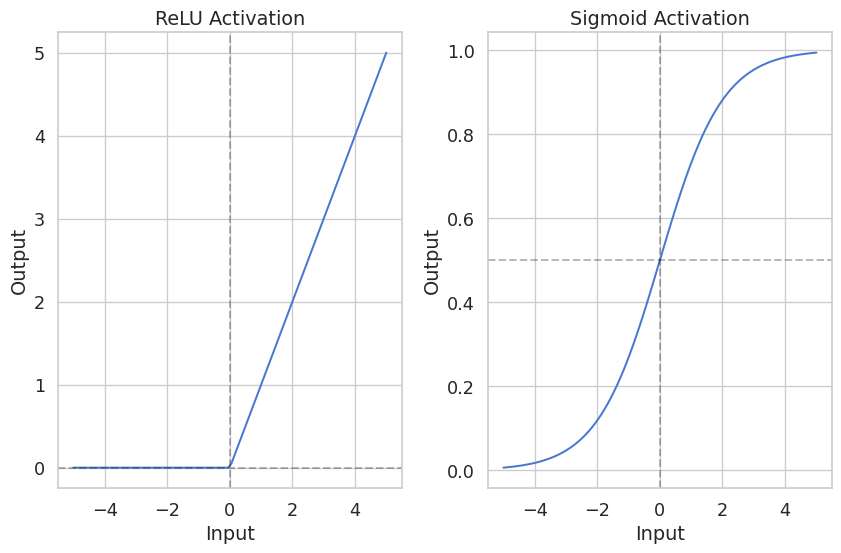

In [8]:
# Visualize activation functions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 6))

x = torch.linspace(-5, 5, 100)
ax1.plot(x.numpy(), F.relu(x).numpy())
ax1.set_title('ReLU Activation')
ax1.set_xlabel('Input')
ax1.set_ylabel('Output')
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)

ax2.plot(x.numpy(), torch.sigmoid(x).numpy())
ax2.set_title('Sigmoid Activation')
ax2.set_xlabel('Input')
ax2.set_ylabel('Output')
ax2.axhline(y=0.5, color='k', linestyle='--', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

------------------------------------------------------------------------

## Why Loss Functions? Teaching a Model What ‘Wrong’ Means

Here’s a hard question: **How does a neural network know it’s wrong?**

In traditional programming, you write rules: “If humidity \> 80%,
predict rain.” You built it, so you know what’s right.

But in machine learning, you **don’t write the rules**. You give the
model data and hope it learns. The model then generates predictions. But
how does it know whether its prediction was good or bad?

**Before Loss Functions Existed (1950s):** Researchers manually adjusted
neural network weights by hand, testing after each change. It took weeks
to train a single small model.

**The Problem:** Without a number quantifying “how wrong” the model is,
there’s no way to improve systematically.

**The Solution: Loss Functions**

A loss function is a **number that measures: “How badly did we mess
up?”**

Examples: - **Mean Squared Error (MSE)**: For regression, how far off
are our predictions? `Loss = average((predicted - actual)²)` - **Binary
Cross-Entropy (BCE)**: For classification (rain/no rain), how confident
was the model in the WRONG answer?

**Why does this matter?**

1.  **Loss gives us direction**: If loss decreases, we’re improving. If
    it increases, we’re going the wrong way.
2.  **Loss is differentiable**: We can calculate how much each weight
    contributed to the loss (using calculus).
3.  **Loss is automated**: Instead of manually testing after each weight
    change, we can automatically find the best weights.

**The Deep Magic**: PyTorch uses automatic differentiation to compute
how much each of the 10 million weights in your model contributed to the
loss. Then it adjusts them all simultaneously to reduce the loss.

This is why loss functions are the bridge between “I have data” and “I
have a trained model.”

------------------------------------------------------------------------

# The Five Sacred Steps of Training

> **Mental Model: Throwing Darts Blindfolded**
>
> Imagine learning to throw darts at a bullseye while **blindfolded**.
> This is exactly what training a neural network feels like!
>
> 1.  **Forward Pass (Throw the dart):** You throw at the board. You
>     have no idea where you aimed!
>
> 2.  **Calculate Loss (Friend yells feedback):** Your friend shouts,
>     “You missed the bullseye by 2 meters to the LEFT!”
>
> 3.  **Backward Pass (Your brain calculates):** You think, “Okay, my
>     right arm was too tense. I need to adjust.”
>
> 4.  **Update Weights (Adjust and throw again):** You shift your stance
>     slightly and throw again.
>
> 5.  **Epoch:** Doing this 100 times until you finally hit the
>     bullseye!
>
> The **Loss Function** is your friend yelling how wrong you are. The
> **Optimizer** is your brain figuring out how to adjust. The **Epochs**
> are the number of throws you take until you get good!

Every neural network training loop follows these exact steps:

## Step 1: Zero Gradients

PyTorch accumulates gradients by default. We must clear them before each
batch.

``` python
optimizer.zero_grad()
```

**Why?** Imagine hiking and wanting to know which way is downhill. You
don’t want to average yesterday’s slope with today’s - you want a fresh
measurement.

## Step 2: Forward Pass

Pass data through the model to get predictions.

``` python
output = model(data)
```

## Step 3: Calculate Loss

Measure how wrong we are.

``` python
loss = criterion(output, target)
```

**Binary Cross Entropy Loss (BCELoss)**: Measures the difference between
predicted probability and true label (0 or 1).

## Step 4: Backward Pass (Backpropagation)

Calculate how much each parameter contributed to the error.

``` python
loss.backward()
```

## Why Not Just Gradient Descent? The Learning Rate Problem

Here’s a sneaky problem: **How much should we adjust the weights?**

After calculating gradients, we know which direction to move (thanks to
backpropagation). But by how much?

**The Naive Approach: Constant Learning Rate**

``` python
new_weight = old_weight - learning_rate * gradient
```

Pick a learning_rate (say, 0.01) and use it for all parameters, all the
time.

**Why this fails:** 1. **Too small learning rate** (0.0001): Training
takes forever. You’re tiptoeing toward the solution. 2. **Too large
learning rate** (0.1): Loss explodes. You’re taking huge steps and
overshooting the solution. 3. **Different parameters need different
rates**: A weight that changes quickly should have a smaller learning
rate than one that changes slowly. 4. **Learning rate should decrease
over time**: Early training needs big steps to explore; late training
needs tiny steps to fine-tune.

**Real-world analogy:** You’re driving a car toward a target (minimal
loss). Constant learning rate is like keeping your foot on the gas at a
fixed position. Too light? Never arrive. Too hard? Crash past the
target. You need to **adjust your speed based on the road ahead** (the
landscape of the loss function).

**The Solution: Adaptive Optimizers**

Optimizers like **Adam** (“Adaptive Moment Estimation”) automatically
adjust the learning rate for each parameter:

- **Learning Rate Adaptation**: Parameters that have been moving
  steadily get smaller updates (slowing down); parameters that are
  bouncing get bigger updates (gaining momentum).
- **Momentum**: Remember the direction you were going. Don’t flip-flop
  between left and right every step.
- **Acceleration**: Speed up when you’re going downhill, slow down when
  the slope flattens.

**Why Adam (or other modern optimizers) dominate:** - You set a starting
learning rate (0.001), and Adam figures out the rest. - It handles
different parameter scales automatically. - It almost never diverges
(loss exploding). - It’s been battle-tested on millions of models
worldwide.

This is why PyTorch uses `optim.Adam` by default, not pure gradient
descent.

------------------------------------------------------------------------

## Step 5: Update Weights

Adjust parameters to reduce the loss.

``` python
optimizer.step()
```

## Complete Training Loop

In [9]:
def train_model(model, X_train, y_train, X_val, y_val, n_epochs=100, lr=0.001):
    """
    Train the neural network.
    """
    # Move data to device
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    X_val = X_val.to(device)
    y_val = y_val.to(device)
    model = model.to(device)
    
    # Define loss function and optimizer
    criterion = nn.BCELoss()  # Binary Cross Entropy for binary classification
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Track history
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }
    
    for epoch in range(n_epochs):
        # Training phase
        model.train()
        
        # Forward pass
        y_pred = model(X_train)
        # Squeeze to match target shape [N] -> both should be 1D
        y_pred = y_pred.squeeze()
        if y_pred.dim() == 0:
            y_pred = y_pred.unsqueeze(0)
        
        # Calculate loss
        loss = criterion(y_pred, y_train)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Calculate training accuracy
        with torch.no_grad():
            predicted = (y_pred >= 0.5).float()
            train_acc = (predicted == y_train).float().mean()
        
        # Validation phase
        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_val)
            # Squeeze to match target shape [N] -> both should be 1D
            y_val_pred = y_val_pred.squeeze()
            if y_val_pred.dim() == 0:
                y_val_pred = y_val_pred.unsqueeze(0)
            val_loss = criterion(y_val_pred, y_val)
            val_predicted = (y_val_pred >= 0.5).float()
            val_acc = (val_predicted == y_val).float().mean()
        
        # Store metrics
        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss.item())
        history['train_acc'].append(train_acc.item())
        history['val_acc'].append(val_acc.item())
        
        # Print progress
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{n_epochs}')
            print(f'  Train Loss: {loss.item():.4f}, Train Acc: {train_acc.item():.4f}')
            print(f'  Val Loss: {val_loss.item():.4f}, Val Acc: {val_acc.item():.4f}')
    
    return model, history

# Split training data into train and validation
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_SEED
)

print(f"Training: {len(X_train_split)} samples")
print(f"Validation: {len(X_val)} samples")
print(f"Test: {len(X_test)} samples")

Training: 20828 samples
Validation: 5208 samples
Test: 6509 samples

### Train the Model

In [10]:
# Train the model
print("Training RainPredictor...")
print("=" * 50)

model, history = train_model(
    model, X_train_split, y_train_split, X_val, y_val, 
    n_epochs=100, lr=0.001
)

print("\nTraining complete!")

Training RainPredictor...
Epoch 10/100
  Train Loss: 5.2639, Train Acc: 0.2331
  Val Loss: 4.6850, Val Acc: 0.2371
Epoch 20/100
  Train Loss: 0.6690, Train Acc: 0.7671
  Val Loss: 0.5677, Val Acc: 0.7629
Epoch 30/100
  Train Loss: 0.9029, Train Acc: 0.7669
  Val Loss: 0.9424, Val Acc: 0.7629
Epoch 40/100
  Train Loss: 0.8666, Train Acc: 0.7670
  Val Loss: 0.8541, Val Acc: 0.7629
Epoch 50/100
  Train Loss: 0.5763, Train Acc: 0.7675
  Val Loss: 0.5672, Val Acc: 0.7629
Epoch 60/100
  Train Loss: 0.5688, Train Acc: 0.7708
  Val Loss: 0.5742, Val Acc: 0.7652
Epoch 70/100
  Train Loss: 0.5048, Train Acc: 0.7837
  Val Loss: 0.4942, Val Acc: 0.7840
Epoch 80/100
  Train Loss: 0.4304, Train Acc: 0.8280
  Val Loss: 0.4308, Val Acc: 0.8331
Epoch 90/100
  Train Loss: 0.4160, Train Acc: 0.8227
  Val Loss: 0.4175, Val Acc: 0.8287
Epoch 100/100
  Train Loss: 0.4115, Train Acc: 0.8302
  Val Loss: 0.4138, Val Acc: 0.8349

Training complete!

## Visualize Training Progress

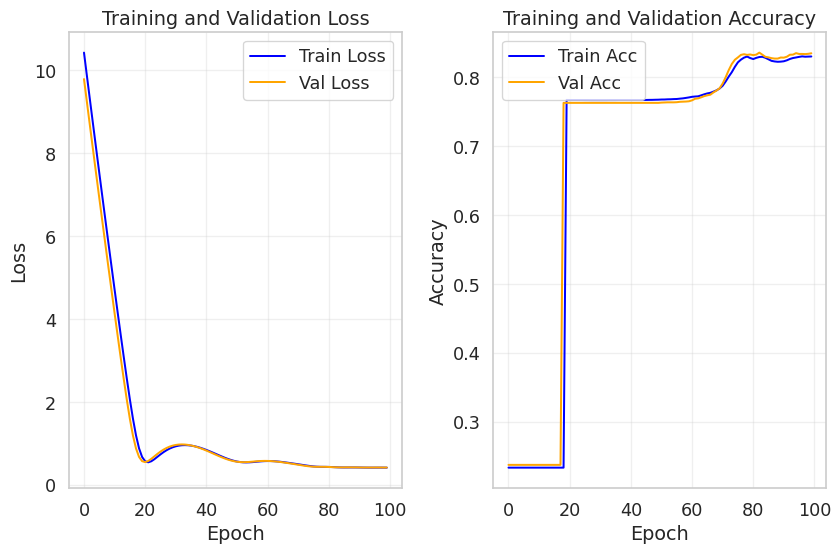

In [11]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 6))

# Loss
ax1.plot(history['train_loss'], label='Train Loss', color='blue')
ax1.plot(history['val_loss'], label='Val Loss', color='orange')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(history['train_acc'], label='Train Acc', color='blue')
ax2.plot(history['val_acc'], label='Val Acc', color='orange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

------------------------------------------------------------------------

# Evaluation and Understanding Predictions

## Test Set Evaluation

In [12]:
# Evaluate on test set
model.eval()
X_test_device = X_test.to(device)
y_test_device = y_test.to(device)

with torch.no_grad():
    y_pred = model(X_test_device)
    y_pred = torch.squeeze(y_pred)
    
    # Convert probabilities to binary predictions
    y_pred_binary = (y_pred >= 0.5).float()
    
    # Calculate accuracy
    test_acc = (y_pred_binary == y_test_device).float().mean()
    print(f"Test Accuracy: {test_acc.item():.4f}")
    
    # Get predictions back to CPU for sklearn metrics
    y_true = y_test_device.cpu().numpy()
    y_pred_labels = y_pred_binary.cpu().numpy()

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_labels, target_names=['No Rain', 'Rain']))

Test Accuracy: 0.8262

Classification Report:
              precision    recall  f1-score   support

     No Rain       0.84      0.95      0.89      4987
        Rain       0.73      0.41      0.53      1522

    accuracy                           0.83      6509
   macro avg       0.78      0.68      0.71      6509
weighted avg       0.81      0.83      0.81      6509


### Understanding the Metrics

- **Accuracy**: Overall correct predictions (but misleading with
  imbalanced data!)
- **Precision**: Of predicted rain days, how many actually rained?
- **Recall**: Of actual rain days, how many did we predict?
- **F1-Score**: Harmonic mean of precision and recall

## Confusion Matrix

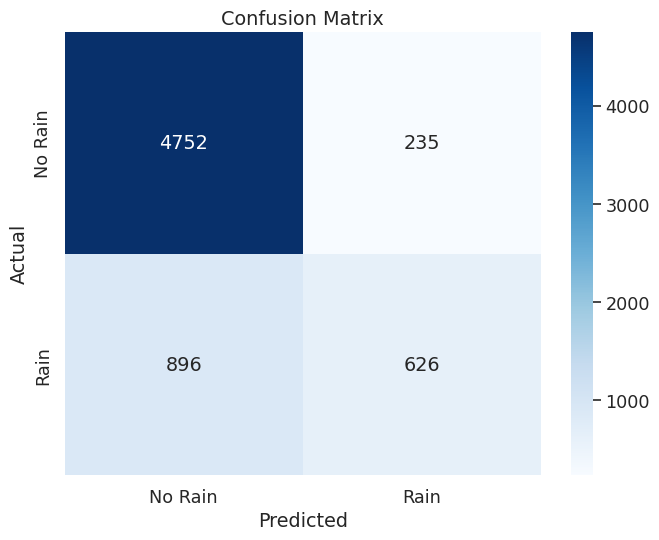

In [13]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Rain', 'Rain'],
            yticklabels=['No Rain', 'Rain'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Analyzing Predictions

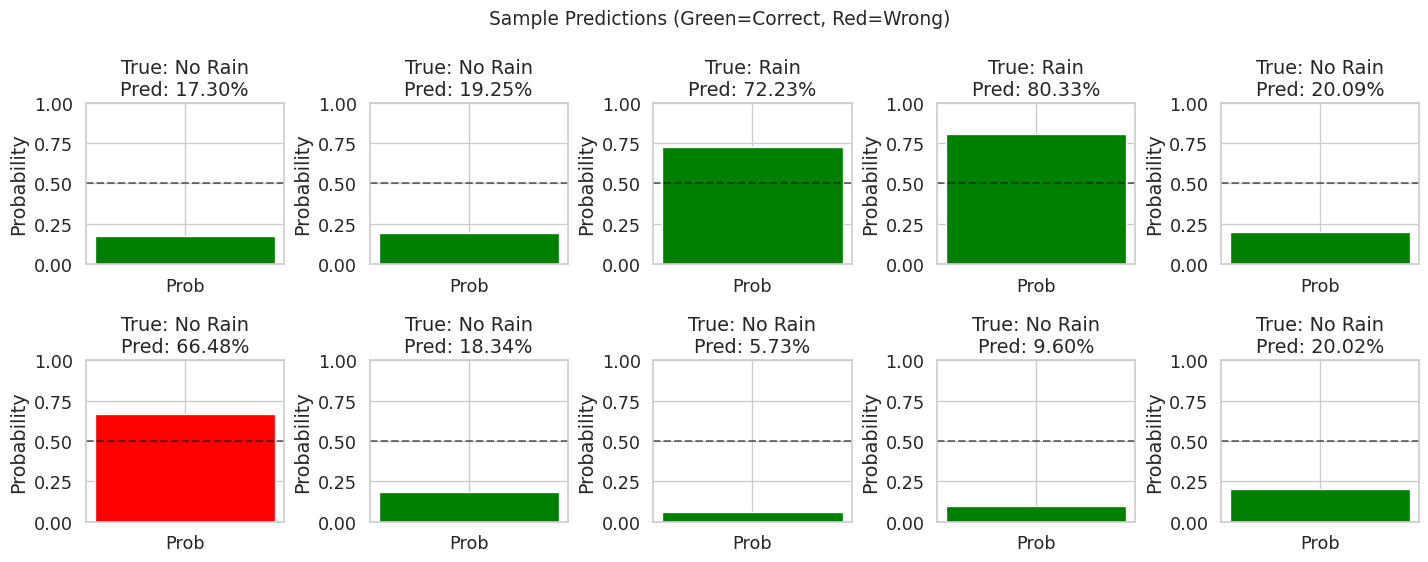

In [14]:
# Show some example predictions
model.eval()
with torch.no_grad():
    sample_indices = np.random.choice(len(X_test), 10, replace=False)
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for i, idx in enumerate(sample_indices):
        sample = X_test[idx].unsqueeze(0).to(device)
        prob = model(sample).item()
        true_label = int(y_test[idx].item())
        pred_label = 1 if prob >= 0.5 else 0
        
        # Get feature values for display
        features = X_test[idx].numpy()
        
        axes[i].bar(['Prob'], [prob], color='green' if pred_label == true_label else 'red')
        axes[i].axhline(y=0.5, color='black', linestyle='--', alpha=0.5)
        axes[i].set_ylim(0, 1)
        axes[i].set_title(f'True: {"Rain" if true_label else "No Rain"}\nPred: {prob:.2%}')
        axes[i].set_ylabel('Probability')
    
    plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14)
    plt.tight_layout()
    plt.show()

------------------------------------------------------------------------

# Deep Learning vs. Machine Learning: When to Use What?

## Why Are We Using Weather Prediction to Learn Deep Learning?

You might be wondering: *“The weather prediction problem we just solved
used **Linear Regression** and **Logistic Regression** - those are
traditional Machine Learning techniques, not Deep Learning! Why are we
in a Deep Learning course?”*

Great question! The answer is that **the weather problem is a
“bridge”** - it helped you understand the fundamentals of:

- Training and testing data
- Features and targets
- Model evaluation (RMSE, Accuracy)
- Overfitting and underfitting

Now, we’re crossing the bridge to Deep Learning. But when should you use
which?

## Machine Learning vs. Deep Learning: The Key Differences

| Aspect | Traditional Machine Learning | Deep Learning |
|:-----------|:-------------------------------------:|:-------------------:|
| **Data Requirements** | Works well with small datasets (100s-10,000s) | Needs large datasets (10,000s - millions) |
| **Feature Engineering** | **You** must manually engineer features | Neural networks **learn** features automatically |
| **Computational Power** | Runs on CPU in seconds/minutes | Requires GPU (or lots of time on CPU) |
| **Interpretability** | Easy to understand (coefficients, trees) | “Black box” - hard to explain decisions |
| **Best For** | Tabular data, structured problems | Images, text, audio, complex patterns |

## When to Use Traditional Machine Learning?

Use **Linear Regression, Logistic Regression, Random Forest, XGBoost**
when:

1.  **You have small data** - Less than 10,000 samples
2.  **Features are already well-understood** - You know which variables
    matter
3.  **You need interpretability** - You must explain the model to
    stakeholders
4.  **Computational resources are limited** - No GPU available
5.  **Quick baseline needed** - ML models train in seconds

**Examples:**

- Predicting house prices (our Ghana housing data!)
- Customer churn prediction
- Credit scoring
- Medical diagnosis with clear biomarkers

## When to Use Deep Learning?

Use **Neural Networks** when:

1.  **You have massive data** - Hundreds of thousands or millions of
    samples
2.  **Data is unstructured** - Images, text, audio, video
3.  **Features are hard to engineer** - You don’t know what features to
    extract
4.  **Complex patterns** - Image recognition, NLP, game playing
5.  **You have GPU** - Training is much faster with graphics cards

**Examples:**

- Image classification (self-driving cars, medical scans)
- Language translation (Google Translate)
- Voice assistants (Alexa, Siri)
- Generating art (DALL-E, Midjourney)

## The Golden Rule

> **“If you can solve it with traditional ML, don’t use Deep
> Learning.”**
>
> - Deep Learning requires more data, more compute, and is harder to
>   debug
> - Start simple! Use Random Forest or XGBoost as your baseline
> - Only move to Deep Learning if ML doesn’t achieve good results

## Our Journey

In this course, we’ll use the **weather problem** to build intuition
about ML fundamentals, then apply those concepts to **neural networks**
that can tackle image data (handwritten digits, traffic signs, and plant
diseases).

------------------------------------------------------------------------

# Understanding MNIST: Images as Numbers

Now that we’ve mastered tabular data with the weather problem, let’s
extend our knowledge to **image data**. This bridges us toward Notebook
2 where we’ll work with color images.

## What is MNIST?

MNIST (Modified National Institute of Standards and Technology) is the
“Hello World” of deep learning:

- **70,000 images** of handwritten digits (0-9)
- **28×28 pixels** each
- **Grayscale**: Each pixel is a single number (0-255)
- **Pre-cleaned and labeled**: Perfect for learning

**Why MNIST matters**: Before tackling complex RGB images, we need to
understand how images become numbers.

## An Image is Just a Grid of Numbers

Let’s load MNIST and see what images really are:

In [15]:
from torchvision import datasets, transforms

# Download MNIST
mnist_train = datasets.MNIST('./data', train=True, download=True)

# Get first image
image, label = mnist_train[0]
print(f"Image type: {type(image)}")
print(f"Image size: {image.size}")
print(f"Label: {label}")

# Convert to numpy to see pixel values
image_array = np.array(image)
print(f"\nImage shape: {image_array.shape}")
print(f"\nPixel value range: {image_array.min()} to {image_array.max()}")
print(f"\nFirst 10x10 pixels:")
print(image_array[:10, :10])

Image type: <class 'PIL.Image.Image'>
Image size: (28, 28)
Label: 5

Image shape: (28, 28)

Pixel value range: 0 to 255

First 10x10 pixels:
[[  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36]
 [  0   0   0   0   0   0   0  49 238 253]
 [  0   0   0   0   0   0   0  18 219 253]
 [  0   0   0   0   0   0   0   0  80 156]]

### Visualizing the Grid

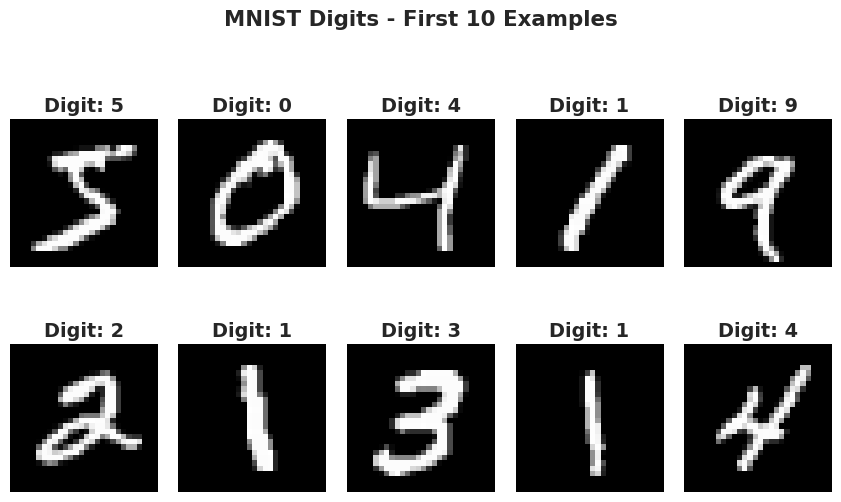

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(9, 6))
axes = axes.flatten()

for i in range(10):
    image, label = mnist_train[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Digit: {label}', fontweight='bold')
    axes[i].axis('off')

plt.suptitle('MNIST Digits - First 10 Examples', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Insight**: What looks like a “7” to your eyes is just a 28×28 grid
of numbers to the computer!

## From 2D Image to 1D Vector

Neural networks expect flat vectors as input. We **flatten** the 28×28
grid into a 784-dimensional vector:

$$28 \times 28 = 784 \text{ pixels}$$

Original shape: (28, 28)
Flattened shape: (784,)

First 50 pixel values:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]

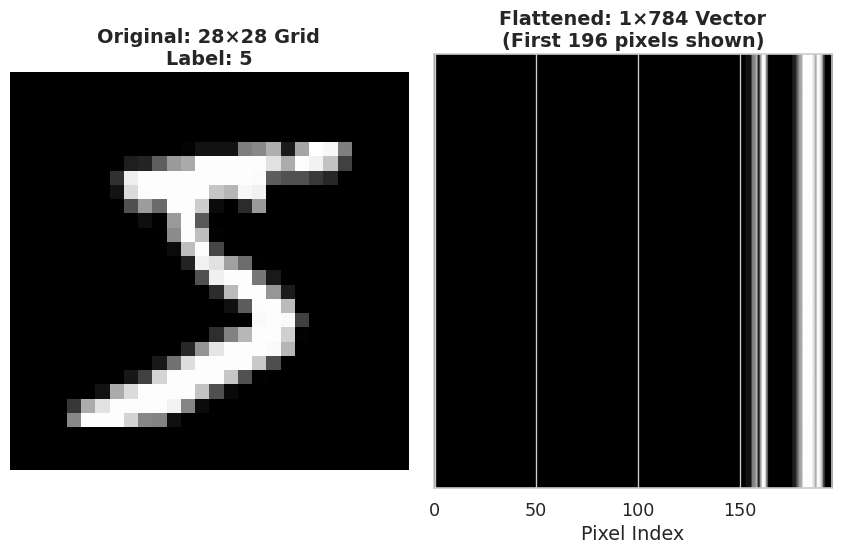

In [17]:
# Show flattening process
sample_idx = 0
image, label = mnist_train[sample_idx]
image_array = np.array(image)

print(f"Original shape: {image_array.shape}")
print(f"Flattened shape: {image_array.flatten().shape}")
print(f"\nFirst 50 pixel values:")
print(image_array.flatten()[:50])

# Visualize the flattening
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 6))

ax1.imshow(image_array, cmap='gray')
ax1.set_title(f'Original: 28×28 Grid\nLabel: {label}', fontweight='bold')
ax1.axis('off')

# Show as a strip
ax2.imshow(image_array.flatten()[:196].reshape(1, -1), cmap='gray', aspect='auto')
ax2.set_title('Flattened: 1×784 Vector\n(First 196 pixels shown)', fontweight='bold')
ax2.set_xlabel('Pixel Index')
ax2.set_yticks([])

plt.tight_layout()
plt.show()

**Why flatten?** Neural network layers (like `nn.Linear`) work with
vectors, not matrices. Each pixel becomes one input feature.

## Simple MNIST Model

Just like our weather predictor, we can build a simple model for MNIST:

In [18]:
class SimpleMNISTNet(nn.Module):
    """
    Simple neural network for MNIST digit classification.
    
    Architecture:
    - Input: 784 pixels (28×28 flattened)
    - Hidden: 128 neurons
    - Output: 10 classes (digits 0-9)
    """
    def __init__(self):
        super(SimpleMNISTNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        x = self.flatten(x)  # (batch, 1, 28, 28) -> (batch, 784)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  # Raw logits (no softmax yet)
        return x

mnist_model = SimpleMNISTNet()
print("MNIST Model Architecture:")
print(mnist_model)

# Count parameters
total_params = sum(p.numel() for p in mnist_model.parameters())
print(f"\nTotal parameters: {total_params:,}")

MNIST Model Architecture:
SimpleMNISTNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 101,770

**Note**: We output 10 values (one per digit) without sigmoid. For
multi-class classification, we’ll use `CrossEntropyLoss` which includes
softmax internally.

## The Power of Pixels

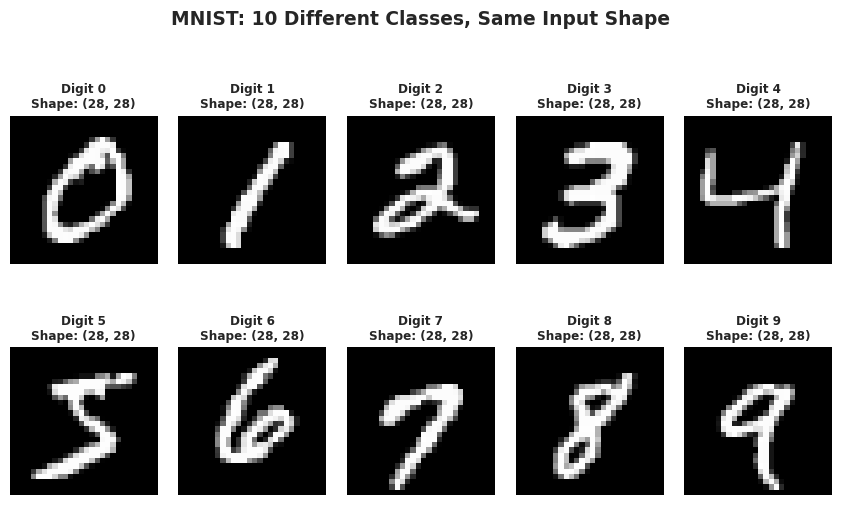

In [19]:
# Visualize what each pixel contributes
fig, axes = plt.subplots(2, 5, figsize=(9, 6))
axes = axes.flatten()

for digit in range(10):
    # Find first example of this digit
    for i in range(len(mnist_train)):
        _, label = mnist_train[i]
        if label == digit:
            image, _ = mnist_train[i]
            break
    
    axes[digit].imshow(image, cmap='gray')
    axes[digit].set_title(f'Digit {digit}\nShape: {np.array(image).shape}', 
                         fontsize=9, fontweight='bold')
    axes[digit].axis('off')

plt.suptitle('MNIST: 10 Different Classes, Same Input Shape', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Bridge to Notebook 2**: MNIST is grayscale (1 channel). In Notebook 2,
we’ll work with **RGB images** which have 3 channels (Red, Green, Blue).
That’s 3× more pixel data!

------------------------------------------------------------------------

# The Chain Rule and Backpropagation: How Networks Learn

We’ve trained models, but **how** do they actually learn? The answer
lies in calculus and the **chain rule**.

## Why This Matters

A neural network with just 1,000 parameters has 1,000 knobs to turn.
Finding the right settings manually would be impossible. We need an
**algorithmic** way to adjust them.

**The Goal**: Minimize the loss function by adjusting weights.

## The Chain Rule: The Foundation of Backpropagation

Remember from calculus: The chain rule tells us how to compute
derivatives of composite functions.

If we have: $$y = f(g(x))$$

Then: $$\frac{dy}{dx} = \frac{dy}{dg} \cdot \frac{dg}{dx}$$

**In neural networks**, we have many composed functions:

$$\text{Loss} = L(\text{Sigmoid}(\text{Linear}_2(\text{ReLU}(\text{Linear}_1(x)))))$$

To find how a weight $w$ in the first layer affects the loss:

$$\frac{\partial \text{Loss}}{\partial w} = 
\frac{\partial \text{Loss}}{\partial \text{Output}} \cdot
\frac{\partial \text{Output}}{\partial \text{Layer2}} \cdot
\frac{\partial \text{Layer2}}{\partial \text{Layer1}} \cdot
\frac{\partial \text{Layer1}}{\partial w}$$

### Visual Example

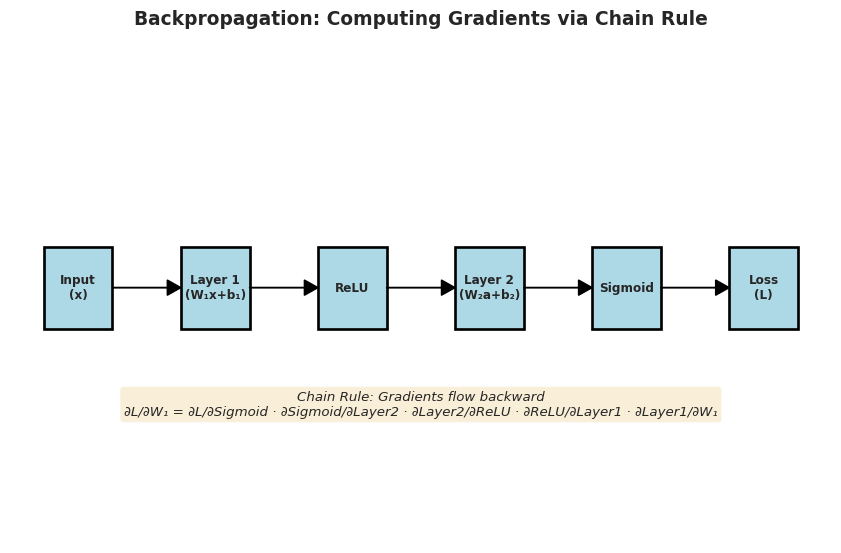

In [20]:
# Create a visualization of the chain rule
fig, ax = plt.subplots(figsize=(9, 6))
ax.axis('off')

# Draw the computation graph
boxes = [
    ('Input\n(x)', 0.1, 0.5),
    ('Layer 1\n(W₁x+b₁)', 0.3, 0.5),
    ('ReLU', 0.5, 0.5),
    ('Layer 2\n(W₂a+b₂)', 0.7, 0.5),
    ('Sigmoid', 0.9, 0.5),
    ('Loss\n(L)', 1.1, 0.5),
]

for text, x, y in boxes:
    ax.add_patch(plt.Rectangle((x-0.05, y-0.08), 0.1, 0.16, 
                                facecolor='lightblue', edgecolor='black', linewidth=2))
    ax.text(x, y, text, ha='center', va='center', fontsize=9, fontweight='bold')

# Draw arrows
for i in range(len(boxes)-1):
    x1 = boxes[i][1] + 0.05
    x2 = boxes[i+1][1] - 0.05
    ax.arrow(x1, boxes[i][2], x2-x1-0.02, 0, head_width=0.03, head_length=0.02, 
             fc='black', ec='black')

# Add chain rule annotation
ax.text(0.6, 0.25, 
        'Chain Rule: Gradients flow backward\n' + 
        '∂L/∂W₁ = ∂L/∂Sigmoid · ∂Sigmoid/∂Layer2 · ∂Layer2/∂ReLU · ∂ReLU/∂Layer1 · ∂Layer1/∂W₁',
        ha='center', fontsize=10, style='italic',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlim(0, 1.2)
ax.set_ylim(0, 1)
ax.set_title('Backpropagation: Computing Gradients via Chain Rule', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Automatic Differentiation in PyTorch

**The Magic**: PyTorch tracks every operation and builds a **computation
graph**. When you call `.backward()`, it automatically applies the chain
rule!

### Simple Example

In [21]:
# Create a simple computation
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

# Forward pass
z = x**2 + y**3
print(f"z = x² + y³ = {x.item()}² + {y.item()}³ = {z.item()}")

# Compute gradients
z.backward()

print(f"\nGradients:")
print(f"∂z/∂x = 2x = 2·{x.item()} = {x.grad.item()}")  # Should be 4
print(f"∂z/∂y = 3y² = 3·{y.item()}² = {y.grad.item()}")  # Should be 27

z = x² + y³ = 2.0² + 3.0³ = 31.0

Gradients:
∂z/∂x = 2x = 2·2.0 = 4.0
∂z/∂y = 3y² = 3·3.0² = 27.0

**What happened?**

- PyTorch remembered that $z = x^2 + y^3$
- When we called `z.backward()`, it computed:
  - $\frac{\partial z}{\partial x} = 2x = 4$
  - $\frac{\partial z}{\partial y} = 3y^2 = 27$

### In Our Neural Network

In [22]:
# Create a simple example with our weather model
sample_model = RainPredictor(4)
sample_input = torch.randn(1, 4)  # Random input
sample_target = torch.tensor([1.0])  # Target: rain

# Forward pass
sample_output = sample_model(sample_input)
# Ensure shapes match: both should be [1] or both scalar
sample_loss = F.binary_cross_entropy(sample_output.squeeze(), sample_target.squeeze())

print(f"Input shape: {sample_input.shape}")
print(f"Output: {sample_output.item():.4f}")
print(f"Loss: {sample_loss.item():.4f}")

# Before backward: gradients are None
print(f"\nBefore backward():")
print(f"First layer weight grad: {sample_model.fc1.weight.grad}")

# Compute gradients
sample_loss.backward()

# After backward: gradients are computed
print(f"\nAfter backward():")
print(f"First layer weight grad shape: {sample_model.fc1.weight.grad.shape}")
print(f"Gradient sample values: {sample_model.fc1.weight.grad[0, :3]}")

Input shape: torch.Size([1, 4])
Output: 0.4404
Loss: 0.8200

Before backward():
First layer weight grad: None

After backward():
First layer weight grad shape: torch.Size([5, 4])
Gradient sample values: tensor([0., 0., 0.])

**Why PyTorch does this**:

- Without autograd, you’d need to manually derive gradients for your
  architecture
- With 50,000+ parameters, manual derivation is impossible
- PyTorch’s dynamic computation graphs make this automatic

## Why `zero_grad()` is Essential

**The Problem**: PyTorch **accumulates** gradients by default. Without
clearing them, gradients add up across batches.

**The Solution**: Call `optimizer.zero_grad()` before each backward
pass.

**Analogy**: You’re hiking and want to know which way is downhill. You
don’t average yesterday’s slope with today’s—you want a fresh
measurement.

In [23]:
# Demonstrate gradient accumulation
demo_model = RainPredictor(4)
demo_optimizer = optim.Adam(demo_model.parameters(), lr=0.001)

print("Demonstrating Gradient Accumulation:")
print("=" * 50)

for i in range(3):
    # Fake batch
    fake_input = torch.randn(4, 4)
    fake_target = torch.tensor([1.0, 0.0, 1.0, 0.0])
    
    # Forward pass
    output = demo_model(fake_input).squeeze()
    loss = F.binary_cross_entropy(output, fake_target)
    
    # WITHOUT zero_grad() - gradients accumulate
    loss.backward()
    
    grad_sum = demo_model.fc1.weight.grad.abs().sum().item()
    print(f"Batch {i+1} - Gradient sum: {grad_sum:.4f}")

print("\nNotice how gradients keep growing! This is bad.")
print("Always call optimizer.zero_grad() before backward().")

Demonstrating Gradient Accumulation:
Batch 1 - Gradient sum: 0.0966
Batch 2 - Gradient sum: 0.1585
Batch 3 - Gradient sum: 0.3625

Notice how gradients keep growing! This is bad.
Always call optimizer.zero_grad() before backward().

## Summary: The Learning Algorithm

1.  **Forward Pass**: Compute predictions and loss
2.  **Backward Pass**: Compute gradients via chain rule (automatic!)
3.  **Update**: Adjust weights using gradients

**The beauty of deep learning**: The chain rule scales to millions of
parameters automatically!

------------------------------------------------------------------------

# Why Not Just Use Accuracy?

**Accuracy** tells you if you’re right or wrong, but not *how* wrong.

**Loss** tells you:

- How far off the prediction is (probability distance)
- Which direction to adjust (gradient)
- How confident the model is (probability magnitude)

We optimize loss, not accuracy, because loss is differentiable and gives
us gradients to follow.

**Key Insight**: With our imbalanced dataset (78% no rain), a model that
always predicts “no rain” gets 78% accuracy! But it’s useless.

That’s why we need precision, recall, and F1-score - they tell us how
well we do on each class.

------------------------------------------------------------------------

# What Happens Without Activation Functions?

Remember: Without non-linearities, stacking layers is pointless:

$$\text{Layer 2}(\text{Layer 1}(x)) = W_2(W_1 x + b_1) + b_2 = W_{combined} x + b_{combined}$$

Two linear layers = one linear layer. No additional power!

**ReLU breaks this**: Now the network can learn: “If feature A AND
feature B are present, activate; otherwise, stay silent.”

------------------------------------------------------------------------

# Summary & Key Takeaways

## What We Learned

| Concept | Description | Importance |
|--------------------|----------------------------|--------------------------|
| **Neural Network** | Stacked layers of linear + non-linear transformations | The foundation of deep learning |
| **ReLU** | Activation function: max(0, x) | Introduces non-linearity |
| **Sigmoid** | Activation function: outputs 0-1 probability | For binary classification |
| **BCELoss** | Binary Cross Entropy Loss | What we optimize for binary tasks |
| **Backpropagation** | Chain rule to compute gradients | How the network learns |
| **Adam Optimizer** | Adaptive learning rate optimization | How we update weights efficiently |

## The Five Sacred Steps

``` python
for each epoch:
    1. optimizer.zero_grad()      # Clear gradients
    2. output = model(data)       # Forward pass
    3. loss = criterion(output, target)  # Compute loss
    4. loss.backward()            # Backpropagation
    5. optimizer.step()           # Update weights
```

## Common Pitfalls to Avoid

❌ **Forgetting `zero_grad()`:** Gradients accumulate, leading to
exploding gradients

❌ **Forgetting `model.eval()` during testing:** Dropout and batch norm
behave differently

❌ **Not using `torch.no_grad()` for inference:** Wastes memory
computing gradients we don’t need

❌ **Wrong input shape:** Always check tensor shapes with `.shape`

❌ **Data not on correct device:** Move tensors to GPU with
`.to(device)`

❌ **Ignoring class imbalance:** Accuracy can be misleading with
imbalanced datasets

## From Here to Production

**Next Steps:**

1.  **Computer Vision:** CNNs for image classification (Notebook 2)
2.  **Transfer Learning:** Leverage pre-trained models (Notebook 3)
3.  **Deployment:** Export models for real-world use

------------------------------------------------------------------------

# Practice Exercises

## Exercise 1: Modify the Network Architecture

Try different architectures and compare results:

In [24]:
class CustomRainPredictor(nn.Module):
    def __init__(self, n_features, hidden_size=10):
        super(CustomRainPredictor, self).__init__()
        # Experiment with:
        # - Number of layers
        # - Number of neurons per layer
        # - With/without dropout
        self.fc1 = nn.Linear(n_features, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

# Your experiments:

# What happens with hidden_size=20 vs hidden_size=5?
# What happens if you add a third hidden layer?
# What happens if you remove the ReLU activations?

## Exercise 2: Learning Rate Experiments

In [25]:
# Try different learning rates and compare convergence:
learning_rates = [0.0001, 0.001, 0.01, 0.1]

for lr in learning_rates:
    model = RainPredictor(X_train.shape[1])
    model, history = train_model(
        model, X_train_split, y_train_split, X_val, y_val,
        n_epochs=50, lr=lr
    )
    final_acc = history['val_acc'][-1]
    print(f"LR {lr}: Final Val Acc = {final_acc:.4f}")
    
# Questions:

# - Which learning rate is too high? (loss explodes)
# - Which learning rate is too low? (slow convergence)
# - What's the sweet spot?

## Exercise 3: Handle Class Imbalance

In [26]:
# Try using class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced', 
    classes=np.unique(y_train.numpy()), 
    y=y_train.numpy()
)
print(f"Class weights: {class_weights}")

# Use weighted loss
criterion = nn.BCELoss(weight=torch.tensor([class_weights[1]]).to(device))

# Does this improve recall for the minority class (rain days)?

## Exercise 4: Feature Importance

In [27]:
# Visualize what the first layer learned
weights = deep_model.layers[0].weight.data.cpu()

fig, axes = plt.subplots(8, 16, figsize=(9, 6))
for i, ax in enumerate(axes.flat):
    if i < weights.shape[0]:
        # Reshape weight to 28x28
        weight_img = weights[i].view(28, 28)
        ax.imshow(weight_img, cmap='RdBu_r')
        ax.axis('off')

plt.suptitle('First Layer Weights (what each neuron looks for)', fontsize=14)
plt.tight_layout()
plt.show()

## Exercise 5: MNIST Exploration

In [28]:
# Load MNIST and explore
from torchvision import datasets

mnist = datasets.MNIST('./data', train=True, download=True)

# Find the digit with the highest average pixel value
avg_pixels = []
for i in range(len(mnist)):
    img, label = mnist[i]
    avg_pixels.append((label, np.array(img).mean()))

# Group by digit and calculate average
import pandas as pd
df_mnist = pd.DataFrame(avg_pixels, columns=['digit', 'avg_pixel'])
avg_by_digit = df_mnist.groupby('digit')['avg_pixel'].mean()

print("Average pixel intensity by digit:")
print(avg_by_digit)

# Which digit is brightest on average? Which is darkest?
# Why might this be? (Think about how digits are written)

## Exercise 6: Chain Rule Practice

In [29]:
# Manual chain rule calculation
import torch

# Define variables
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

# Define computation: z = (x + y)²
z = (x + y) ** 2

# Compute gradients
z.backward()

# Manual calculation:
# z = (x + y)²
# ∂z/∂x = 2(x + y) = 2(2 + 3) = 10
# ∂z/∂y = 2(x + y) = 2(2 + 3) = 10

print(f"PyTorch gradient for x: {x.grad.item()}")
print(f"Manual gradient for x: {2 * (2 + 3)}")
print(f"PyTorch gradient for y: {y.grad.item()}")
print(f"Manual gradient for y: {2 * (2 + 3)}")

# Do they match? Try with your own computation!

------------------------------------------------------------------------

**Congratulations!** You’ve built your first neural network from scratch
and trained it on real tabular data.

You learned:

- How neural networks work (layers, activations, forward pass)
- How images become numbers (MNIST)
- How networks learn via backpropagation and the chain rule
- How to evaluate models beyond just accuracy
- Common pitfalls and how to avoid them

**Your Journey So Far:**

1.  **Tabular Data** (Weather) ← You are here
2.  **Images as Numbers** (MNIST) ← Understanding pixels
3.  **Chain Rule** ← Understanding learning
4.  **Computer Vision** (CNNs) → Next: Notebook 2
5.  **Transfer Learning** → Next: Notebook 3

*“The best way to learn deep learning is to build something that fails,
understand why, and fix it. Repeat until it works, then repeat until
it’s beautiful.”*